In [79]:
import os
import pandas as pd
import numpy as np
import networkx as nx 
import matplotlib.pyplot as plt
# from community import community_louvain 
# from networkx.algorithms.community import kernighan_lin_bisection
from networkx.algorithms.community import greedy_modularity_communities, modularity
from scipy.stats import spearmanr
import torch

In [80]:
def read_data(num_nodes=-1):

    """ Reads data of politician, their party and who they follow into df_data """

    members = pd.read_csv('raw_data/raw_data/all_congress_members.csv')
    members['current_twitter_name'] = members['new_twitter_name'].fillna(members['twitter_name'])

    df_data = pd.DataFrame()
    df_data[['current_twitter_name','party']] = members[['current_twitter_name','party']].copy()
    if num_nodes != -1:
        df_data = df_data.head(num_nodes)

    following_data = []
    
    for twitter_name in df_data['current_twitter_name']:
        filename = f"twitterExport_{twitter_name}_Following.csv"
        filepath = os.path.join('raw_data/raw_data/following_data_raw', filename)

        if os.path.exists(filepath):
            followed_users = pd.read_csv(filepath)['user_name'].tolist()
        else:
            followed_users = []
        
        following_data.append(followed_users)

    df_data['complete_following'] = following_data
    df_data = df_data[df_data['complete_following'].apply(lambda x: x != [])]

    # Convert the list of all current twitter names to a set for faster lookup
    current_names_set = set(df_data['current_twitter_name'].values)

    # Filter out following names that also appear in df_data['current_twitter_name']
    filtered_following_data = []
    for follow_list in df_data['complete_following']:
        filtered_list = [name for name in follow_list if name not in current_names_set]
        filtered_following_data.append(filtered_list)

    df_data['following'] = filtered_following_data
    df_data = df_data[df_data['following'].apply(lambda x: x != [])]

    republican_df = df_data[df_data['party'] == "R"]
    democratic_df = df_data[df_data['party'] == "D"]

    return df_data, republican_df, democratic_df

In [81]:
def build_network(df_data, k, hits, weighted):

    """ Builds network of politicians, with edges between them if they share k followers """

    G = nx.Graph()
    
    # Add nodes
    names = df_data['current_twitter_name'].tolist()

    for _, row in df_data.iterrows():
        politician = row['current_twitter_name']        
        G.add_node(politician, party=row['party'])
    
    # Add edges based on shared following
    for i in range(len(df_data)):
        for j in range(i + 1, len(df_data)):
            # Get the sets of following of each politcian
            # Uses the "important_following" column if we incorporate hits, otherwise defaults to the "following" column
            if hits:
                following_i = set(df_data.iloc[i]['important_following'])
                following_j = set(df_data.iloc[j]['important_following'])
            else:
                following_i = set(df_data.iloc[i]['following'])
                following_j = set(df_data.iloc[j]['following'])
            
            # Get the shared following
            shared_following = following_i.intersection(following_j)
            if len(shared_following) >= k:
                if weighted == False:
                    G.add_edge(names[i], names[j])
                else:
                    G.add_edge(names[i], names[j], weight=len(shared_following))
    
    return G

In [82]:
def build_weighted_network(df_data, k, hits):

    """ Builds network of politicians, with edges between them if they share k followers """

    G = nx.Graph()
    
    # Add nodes
    names = df_data['current_twitter_name'].tolist()
    
    for _, row in df_data.iterrows():
        politician = row['current_twitter_name']        
        G.add_node(politician, party=row['party'])
    
    # Add edges based on shared following
    for i in range(len(df_data)):
        for j in range(i + 1, len(df_data)):
            # Get the sets of following of each politcian
            # Uses the "important_following" column if we incorporate hits, otherwise defaults to the "following" column
            if hits:
                following_i = set(df_data.iloc[i]['important_following'])
                following_j = set(df_data.iloc[j]['important_following'])
            else:
                following_i = set(df_data.iloc[i]['following'])
                following_j = set(df_data.iloc[j]['following'])
            
            # Get the shared following
            shared_following = following_i.intersection(following_j)
            if len(shared_following) >= k:
                G.add_edge(names[i], names[j], weight=len(shared_following))
    
    print(nx.is_weighted(G))
    return G

In [83]:
def classify_communities(alignment):
    ratio_list = []
    community_label = {}
    for community_id, parties_total in alignment.items():
        ratio = parties_total['R']/(parties_total['R']+parties_total['D'])
        ratio_list.append(ratio)

    if ratio_list[0]>ratio_list[1]:
        Republican = 1
        Democrat = 2
    else:
        Republican = 2
        Democrat = 1

    community_label[Republican] = 'Republican'
    community_label[Democrat] = 'Democrat' 
    # print(ratio_list, community_label)
    return community_label
    

In [84]:
def merge_communities_by_edge_count(G, communities):
    """Merge a list of communities into exactly two based on the edge counts between them.

    Args:
        G (networkx.Graph): The graph from which the communities are derived.
        communities (list of set): List of communities to merge, where each community is a set of nodes.

    Returns:
        list of set: Two communities merged based on edge connectivity.
    """
    if len(communities) < 2:
        raise ValueError("There must be at least two communities to merge into two.")
    
    # Convert frozensets or other iterables to sets if necessary
    communities = [set(community) for community in communities]
    
    # Sort communities by size in descending order
    communities = sorted(communities, key=len, reverse=True)
    
    # Start with the two largest communities
    large_community_one, large_community_two = communities[:2]
    
    # Function to count edges between two sets of nodes
    def count_edges_between(set1, set2):
        return sum(1 for node in set1 if set(G.neighbors(node)) & set2)

    # Merge remaining communities into one of these two
    for community in communities[2:]:
        edges_to_one = count_edges_between(community, large_community_one)
        edges_to_two = count_edges_between(community, large_community_two)
        
        if edges_to_one > edges_to_two:
            large_community_one.update(community)
        else:
            large_community_two.update(community)

    return [large_community_one, large_community_two]

In [85]:
from networkx.algorithms.community import greedy_modularity_communities, modularity

def apply_greedy_modularity_two_partitions(G):
    """Applies greedy modularity community detection and merges results into two communities.

    Args:
        G (networkx.Graph): The graph on which to apply the community detection.

    Returns:
        tuple: Contains the two communities, party alignment, modularity of the partition, and community labels.
    """
    # Detect communities using greedy modularity maximization
    initial_communities = greedy_modularity_communities(G)
    # print(len(initial_communities))

    # Merge communities into two
    if len(initial_communities) > 2:
        communities = merge_communities_by_edge_count(G, initial_communities)
        # communities = merge_communities_max_modularity(G, initial_communities)
        # communities = merge_into_two_communities(initial_communities)
    else:
        communities = [set(community) for community in initial_communities]

    # Analyze alignment with political parties
    alignment = {1: {'R': 0, 'D': 0}, 2: {'R': 0, 'D': 0}}
    for idx, community in enumerate(communities):
        for node in community:
            party = G.nodes[node]['party']
            alignment[idx + 1][party] += 1

    # Calculate modularity for the two communities
    mod_value = modularity(G, communities)
    # print(f"Modularity of the partition: {mod_value}")

    # Classify communities based on dominant party
    comm_labels = classify_communities(alignment)

    return communities, alignment, mod_value, comm_labels


In [86]:
def calculate_metrics(alignment, community_label):
    """
    Calculate FFC, ARI, RI, and NMI from alignment data and graph nodes.

    Parameters:
        alignment (dict): Alignment data of communities to political parties.
        node_to_community (dict): Mapping of nodes to their assigned community.
        G (Graph): The graph with nodes and party information.

    Returns:
        dict: Calculated metrics.
    """
    # print(community_label[1])
    if community_label[1] == 'Republican':
        Republican = 1
        Democrat = 2
    else:
        Republican = 2
        Democrat = 1

    # print(Republican, Democrat)
    # Extract counts
    true_positive_R = alignment[Republican]["R"]
    false_positive_R = alignment[Republican]["D"]
    true_positive_D = alignment[Democrat]["D"]
    false_positive_D = alignment[Democrat]["R"]
    # Precision and Recall for R
    precision_R = true_positive_R / (true_positive_R + false_positive_R) if (true_positive_R + false_positive_R) > 0 else 0
    recall_R = true_positive_R / (true_positive_R + false_positive_D) if (true_positive_R + false_positive_D) > 0 else 0
    
    # Precision and Recall for D
    precision_D = true_positive_D / (true_positive_D + false_positive_D) if (true_positive_D + false_positive_D) > 0 else 0
    recall_D = true_positive_D / (true_positive_D + false_positive_R) if (true_positive_D + false_positive_R) > 0 else 0

    # Macro Average (Optional)
    precision_macro = (precision_R + precision_D) / 2
    recall_macro = (recall_R + recall_D) / 2

    f1_score = 2*precision_macro*recall_macro/(precision_macro+recall_macro)  if (precision_macro+recall_macro) > 0 else 0
    accuracy = (true_positive_R+true_positive_D)/(true_positive_D+true_positive_R+false_positive_R+false_positive_D)


    return {
        # "precision": precision_macro,
        # "recall": recall_macro,
        "accuracy": accuracy,
        "f1": f1_score
    }


In [87]:
def visualise_graph(G, communities, spacing, title):
    """ Visualize graph colored red and blue for R and D classed by louvain algorithm respectively """

    # Determine community membership
    community1 = set(communities[0])
    community2 = set(G.nodes()) - community1
    
    plt.figure(figsize=(20, 15))
    node_colors = ['red' if node in community1 else 'lightskyblue' for node in G.nodes()]
    
    # Custom layout: Increase spacing between nodes of different communities
    pos = nx.spring_layout(G, k=spacing * (1 + np.sqrt(len(G.nodes()))), iterations=50)
    
    # Draw communities in separate locations
    # You can create a dictionary of positions manually if needed to separate communities further
    community_pos = {}
    for node in community1:
        community_pos[node] = pos[node] + np.array([1, 0])  # Shift one community right
    for node in community2:
        community_pos[node] = pos[node] + np.array([-1, 0])  # Shift one community left

    # nx.draw_networkx_edges(G, pos, alpha=0.05, width=0.1)
    nx.draw(G, pos=community_pos, with_labels=True, node_color=node_colors, node_size=2000, font_size=16)
    plt.title(title, fontsize=16)
    plt.show()

In [88]:
""" PARAMETERS """

# num of politicians used out of 164 total (-1 means all politicians)
num_nodes = -1 
# min num of shared followers to have a link
follow_thresh = 15
# spacing between the network nodes (higher value gives more spacing)
spacing = 15

In [89]:
df_data, republican_df, democratic_df = read_data(num_nodes)
G = build_network(df_data, follow_thresh, False, False)
# df_data

In [71]:
G_weight = build_weighted_network(df_data, follow_thresh, False)


True


In [72]:
communities, alignment, mod_value, comm_label = apply_greedy_modularity_two_partitions(G)
print(alignment)
print(calculate_metrics(alignment, comm_label))

{1: {'R': 85, 'D': 1}, 2: {'R': 6, 'D': 72}}
{'accuracy': 0.9573170731707317, 'f1': 0.9579488908325434}


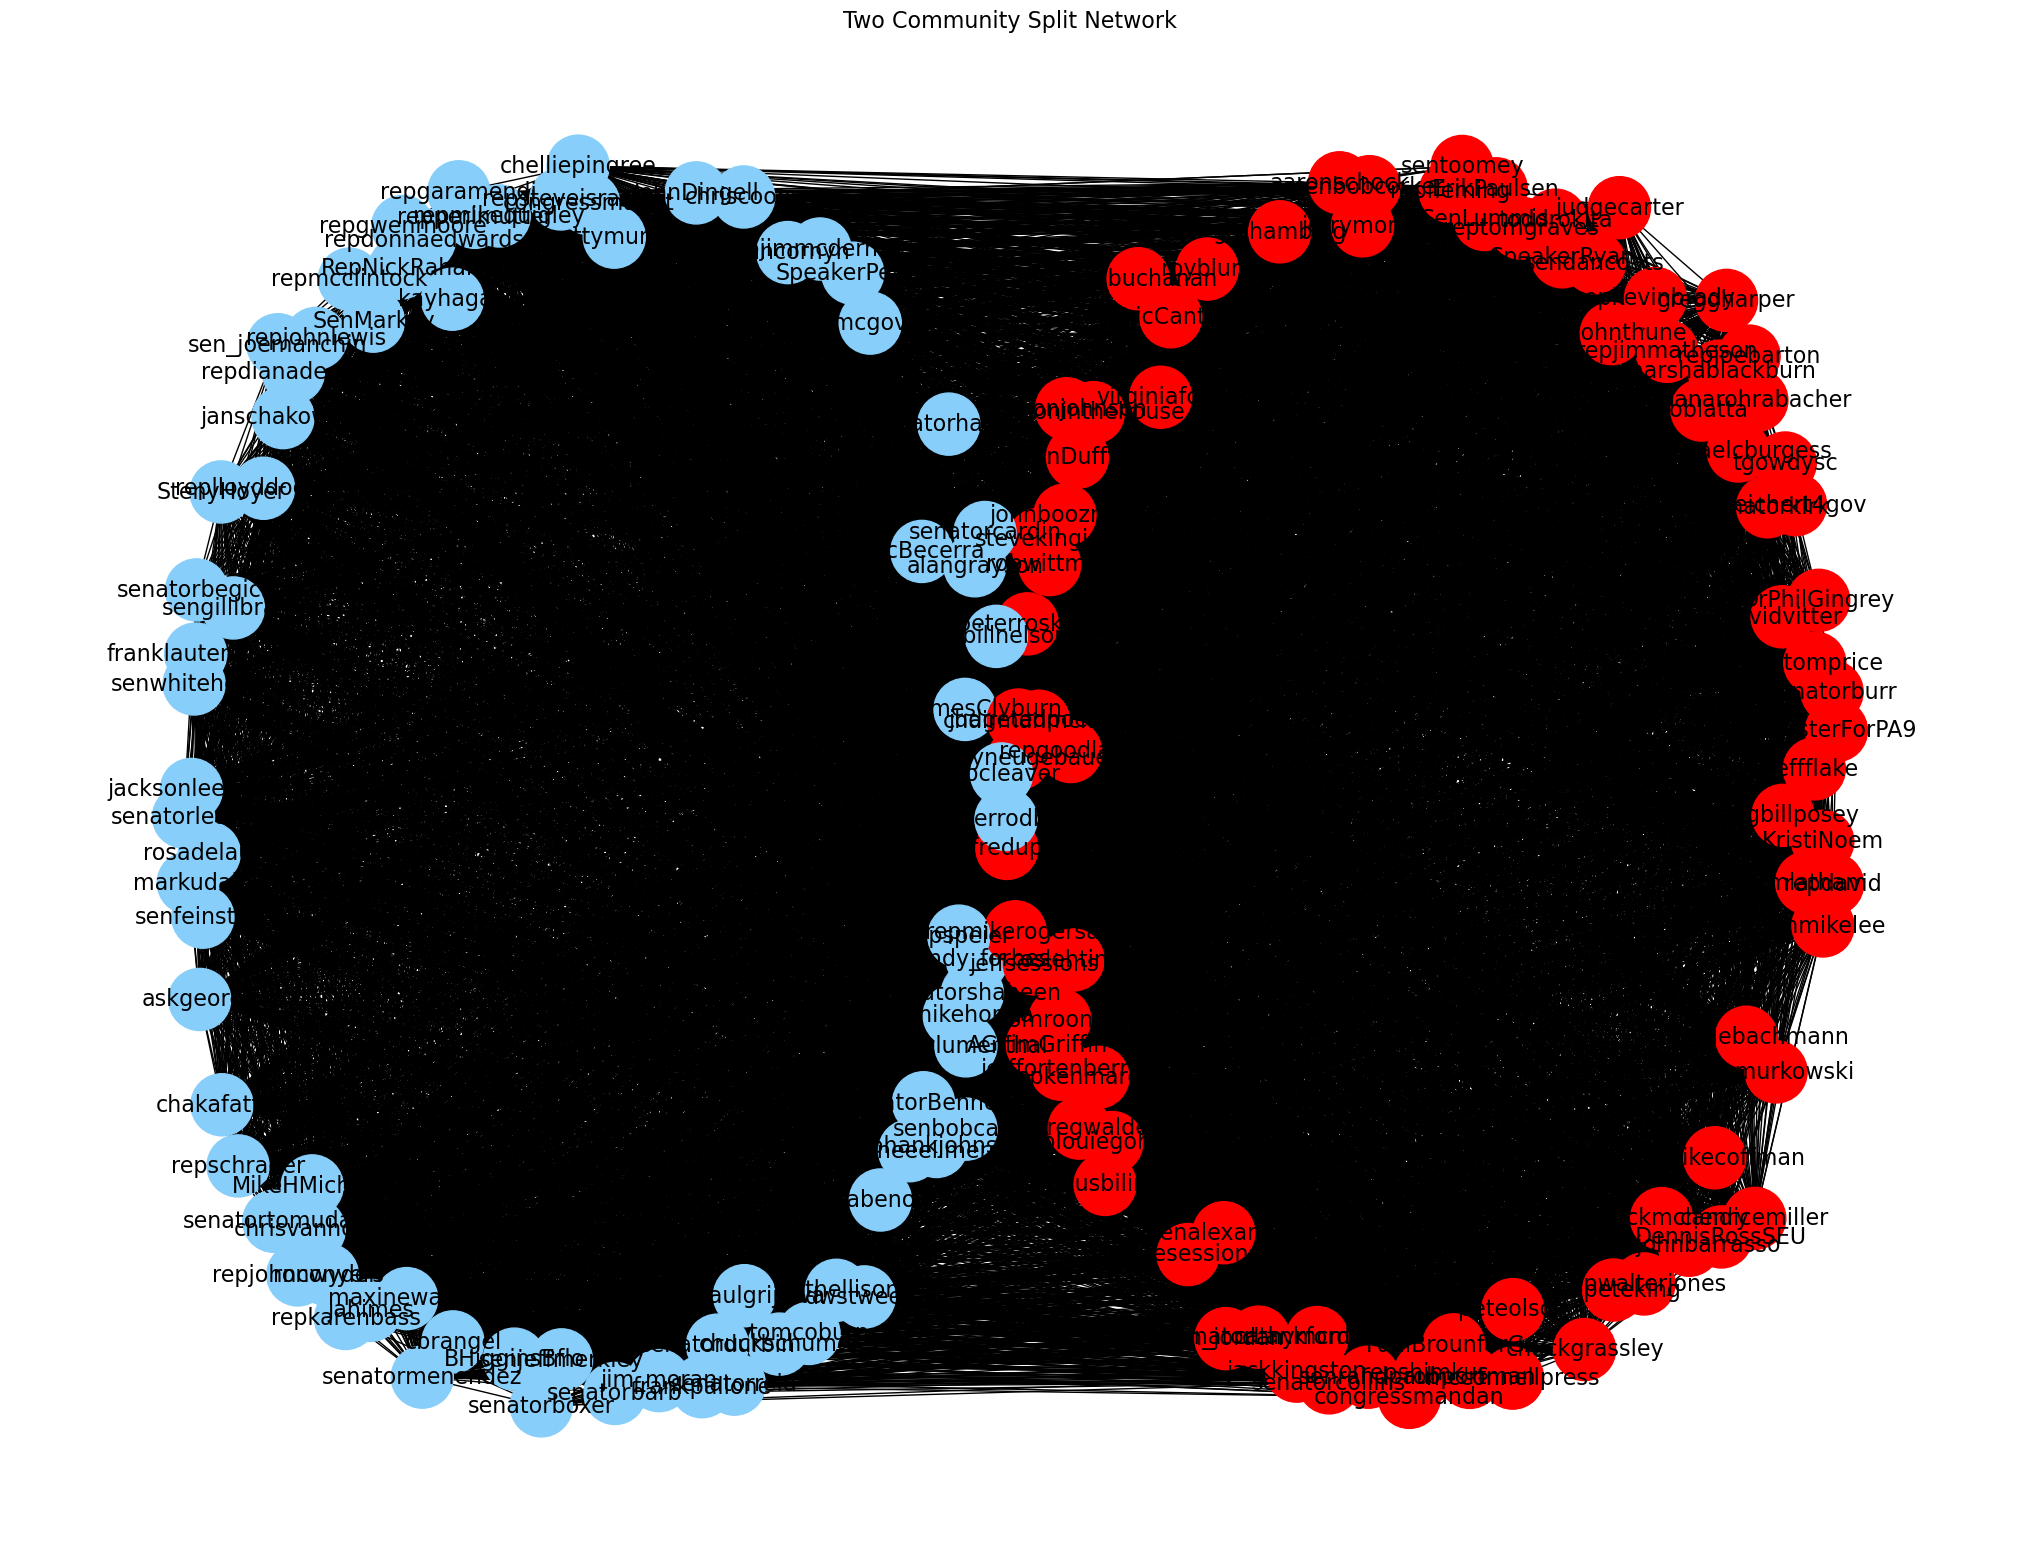

In [73]:
title = "Two Community Split Network"
visualise_graph(G, communities, spacing, title)

In [74]:
communities, alignment, mod_value, comm_label = apply_greedy_modularity_two_partitions(G_weight)
print(alignment)
print(calculate_metrics(alignment, comm_label))

{1: {'R': 85, 'D': 1}, 2: {'R': 6, 'D': 72}}
{'accuracy': 0.9573170731707317, 'f1': 0.9579488908325434}


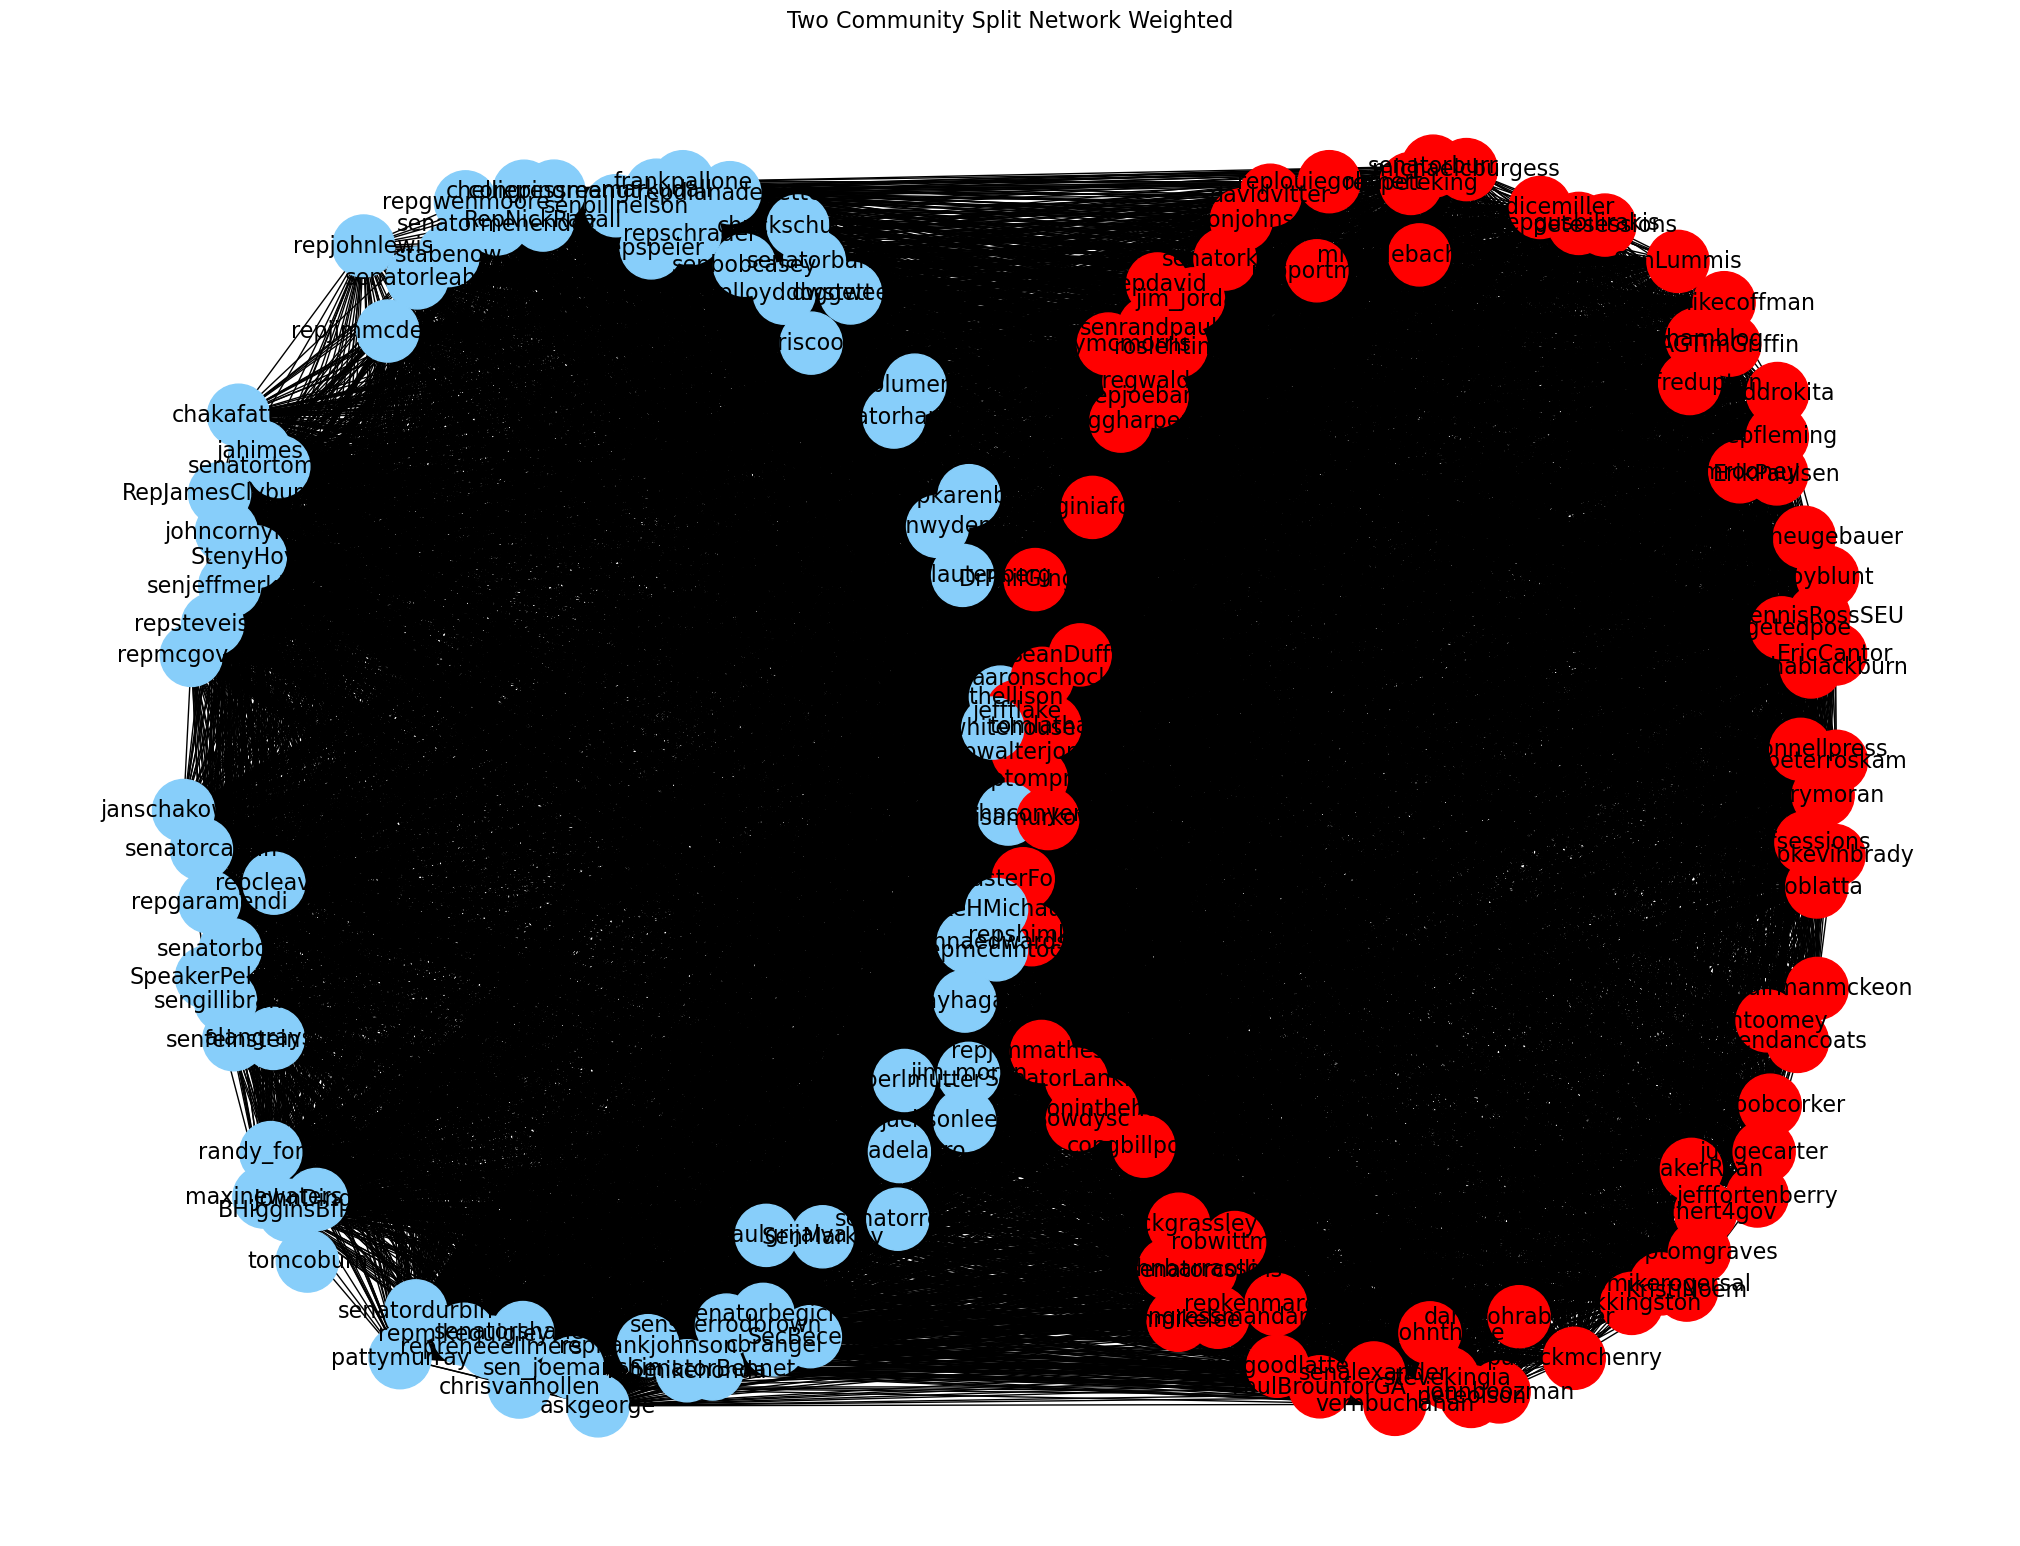

In [75]:
title = "Two Community Split Network Weighted"
visualise_graph(G_weight, communities, spacing, title)

In [76]:
nx.write_gexf(G, "origG.gexf")
nx.write_gexf(G_weight, "weightG.gexf")


In [90]:
def analyze_networks(df_data):
    thresholds = range(1, 21, 1)
    modularities = {'G': [], 'G_weighted': []}
    accuracies = {'G': [], 'G_weighted': []}
    f1_scores = {'G': [], 'G_weighted': []}

    for threshold in thresholds:
        # Build both graphs for each threshold
        G = build_network(df_data, threshold, False, False)
        G_weighted = build_network(df_data, threshold, False, True)
        
        for graph_label, graph in [('G', G), ('G_weighted', G_weighted)]:
            # Apply community detection
            communities, alignment, mod_value, comm_label = apply_greedy_modularity_two_partitions(graph)
            
            # Calculate metrics
            metrics = calculate_metrics(alignment, comm_label)
            
            # Store results
            modularities[graph_label].append(mod_value)
            accuracies[graph_label].append(metrics['accuracy'])
            f1_scores[graph_label].append(metrics['f1'])

    # Plotting results
    fig, axes = plt.subplots(3, 1, figsize=(10, 15))
    # Modularity Plot
    axes[0].plot(thresholds, modularities['G'], label='G - Modularity')
    axes[0].plot(thresholds, modularities['G_weighted'], label='G_weighted - Modularity')
    axes[0].set_xlabel('Threshold')
    axes[0].set_ylabel('Modularity')
    axes[0].set_title("Comparing Weighted vs Unweighted Graph's Modularity against Threshold")
    axes[0].legend()

    # Accuracy Plot
    axes[1].plot(thresholds, accuracies['G'], label='G - Accuracy')
    axes[1].plot(thresholds, accuracies['G_weighted'], label='G_weighted - Accuracy')
    axes[1].set_xlabel('Threshold')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_title("Comparing Weighted vs Unweighted Graph's Accuracy vs. Threshold")
    axes[1].legend()

    # F1 Score Plot
    axes[2].plot(thresholds, f1_scores['G'], label='G - F1 Score')
    axes[2].plot(thresholds, f1_scores['G_weighted'], label='G_weighted - F1 Score')
    axes[2].set_xlabel('Threshold')
    axes[2].set_ylabel('F1 Score')
    axes[2].set_title("Comparing Weighted vs Unweighted Graph's F1 Score vs. Threshold")
    axes[2].legend()

    plt.tight_layout()
    plt.show()


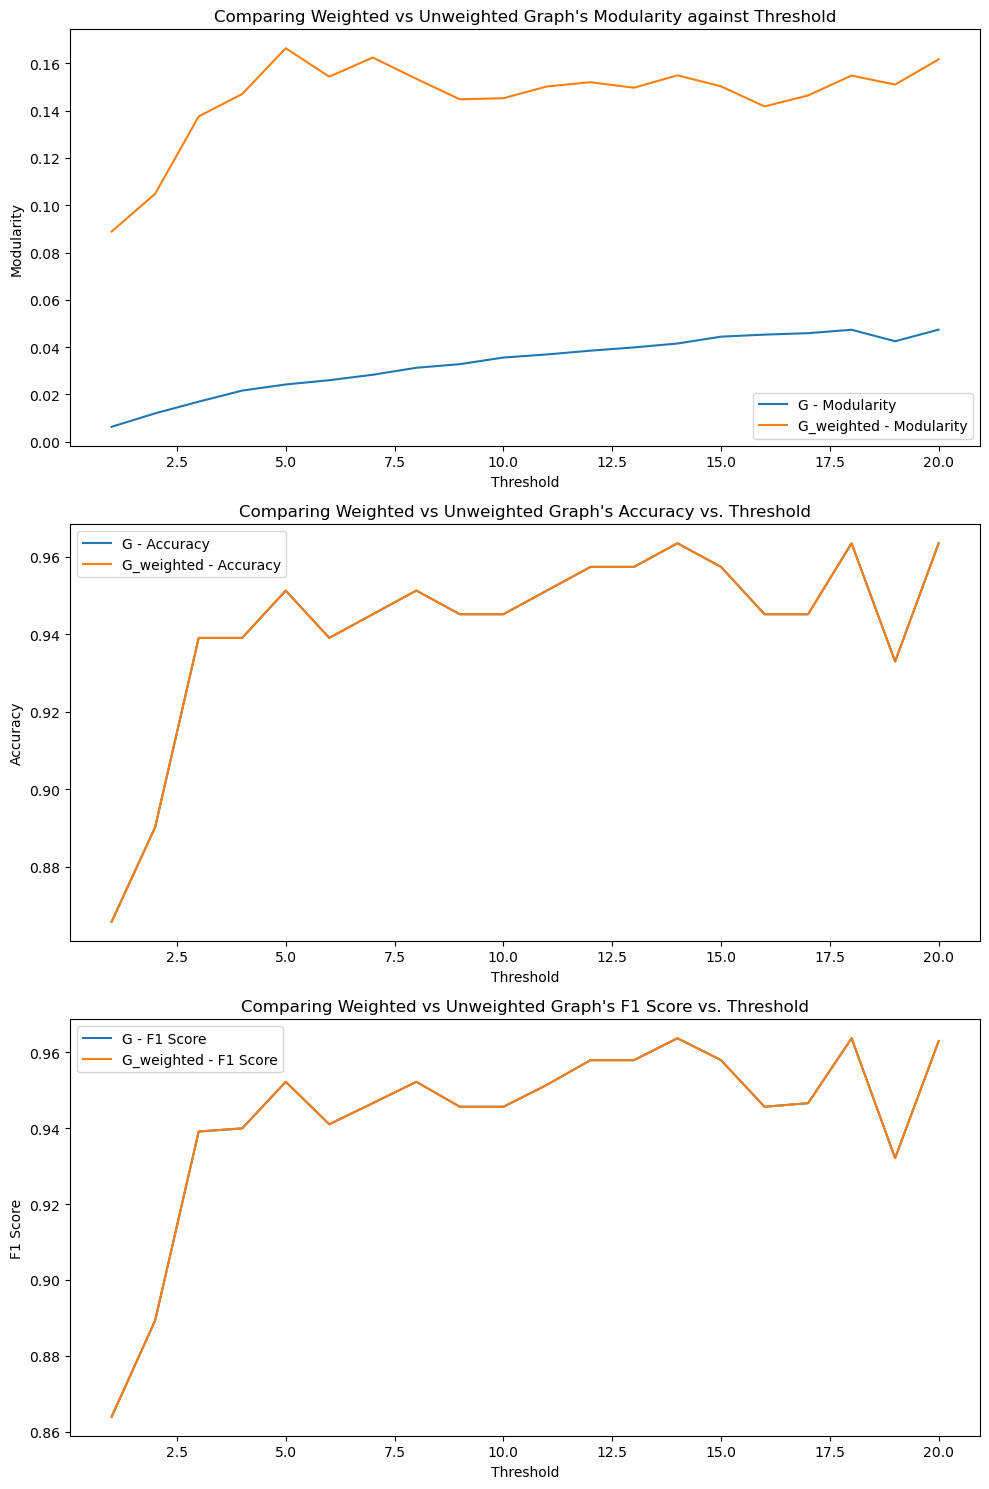

In [91]:
analyze_networks(df_data)